
V_R1s(r) =
+216.0548 * exp(-23.7265 r)
+152.6162 * r * exp(-20.2915 r)
+0.3828 * r * exp(-9.4802 r)
+537.1859 * r^2 * exp(-29.1499 r)
+0.0451 * r^2 * exp(-6.9463 r)
-0.0207 * r^2 * exp(-4.9127 r)
+0.0012 * r^2 * exp(-3.3257 r)
-1.6573 * r^3 * exp(-11.2844 r)
-0.0000 * r^3 * exp(-1.9549 r)
+0.0000 * r^3 * exp(-1.2721 r)
-0.0000 * r^3 * exp(-0.8656 r)

V_R2s(r) =
-64.3278 * exp(-23.7265 r)
-371.6394 * r * exp(-20.2915 r)
+326.8487 * r * exp(-9.4802 r)
-63.3775 * r^2 * exp(-29.1499 r)
+30.1456 * r^2 * exp(-6.9463 r)
-0.9382 * r^2 * exp(-4.9127 r)
+0.0888 * r^2 * exp(-3.3257 r)
+403.1938 * r^3 * exp(-11.2844 r)
-0.0009 * r^3 * exp(-1.9549 r)
+0.0001 * r^3 * exp(-1.2721 r)
-0.0000 * r^3 * exp(-0.8656 r)

V_R3s(r) =
-23.2634 * exp(-23.7265 r)
-154.9121 * r * exp(-20.2915 r)
+139.2302 * r * exp(-9.4802 r)
-63.9977 * r^2 * exp(-29.1499 r)
+38.3541 * r^2 * exp(-6.9463 r)
-67.7970 * r^2 * exp(-4.9127 r)
-16.9664 * r^2 * exp(-3.3257 r)
+554.9869 * r^3 * exp(-11.2844 r)
-0.0175 * r^3 * exp(-1.954

/tmp/ipykernel_9433/3371354097.py:129: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)


Norm 1s = 0.9995442367050871
Norm 2s = 0.9999577765867276
Norm 2p = 1.0000007879956259
Norm 3s = 0.9999954882351995
Norm 3p = 0.9999993198191292
Norm 3d = 1.0000015508650284
Norm 4s = 1.0000000698064313
           Q  J_1s_one_electron  J_2s_one_electron  J_3s_one_electron  \
0       0.00           0.038106       1.469986e-01       4.154822e-01   
1       0.05           0.038106       1.469664e-01       4.146893e-01   
2       0.10           0.038104       1.468698e-01       4.123210e-01   
3       0.15           0.038101       1.467090e-01       4.084083e-01   
4       0.20           0.038097       1.464841e-01       4.030015e-01   
...      ...                ...                ...                ...   
1996   99.80           0.000003       2.813042e-07       3.710236e-08   
1997   99.85           0.000003       2.800645e-07       3.693867e-08   
1998   99.90           0.000003       2.788289e-07       3.677552e-08   
1999   99.95           0.000003       2.775975e-07       3.661293e-

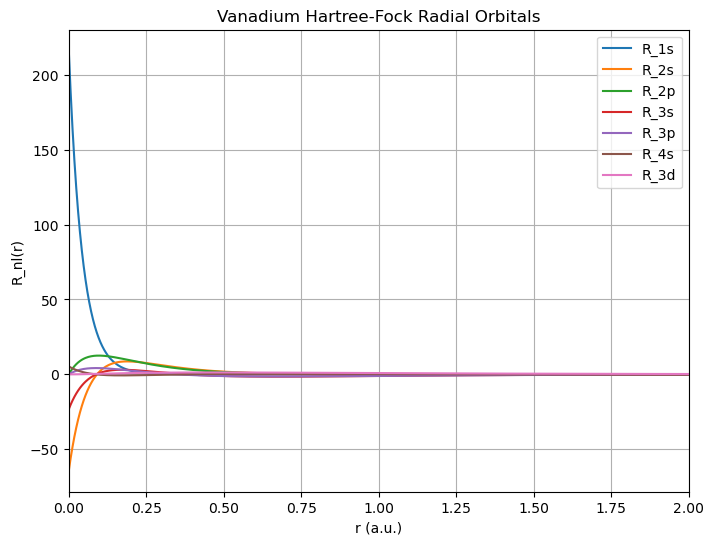

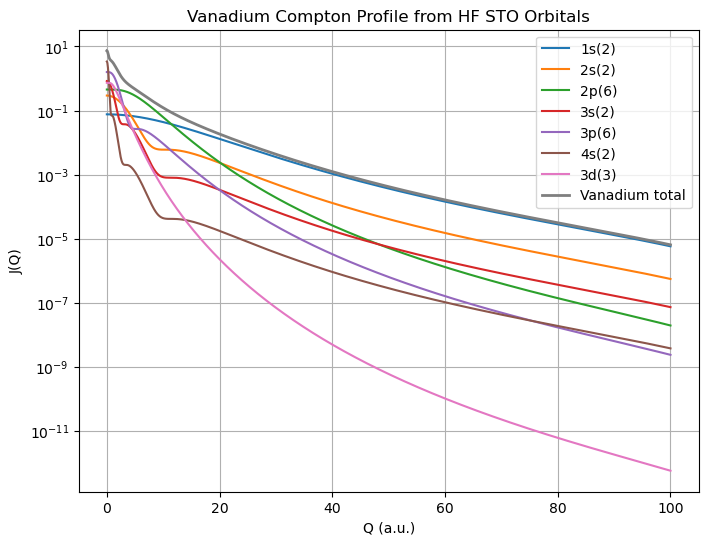

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Vanadium Hartree-Fock STO data
# V: 1s(2) 2s(2) 2p(6) 3s(2) 3p(6) 3d(3) 4s(2)
# Format: (n_j, Z_j, C_j)
# =====================================================

vanadium_1s = [
    (1,23.7265,  0.934724),
    (2,20.2915,  0.071260),
    (2, 9.4802,  0.001198),
    (3,29.1499,  0.009527),
    (3, 6.9463,  0.000121),
    (3, 4.9127, -0.000187),
    (3, 3.3257,  0.000044),
    (4,11.2844, -0.000270),
    (4, 1.9549, -0.000015),
    (4, 1.2721,  0.000011),
    (4, 0.8656, -0.000004),
]

vanadium_2s = [
    (1,23.7265, -0.278303),
    (2,20.2915, -0.173527),
    (2, 9.4802,  1.022901),
    (3,29.1499, -0.001124),
    (3, 6.9463,  0.080937),
    (3, 4.9127, -0.008467),
    (3, 3.3257,  0.003140),
    (4,11.2844,  0.065688),
    (4, 1.9549, -0.000372),
    (4, 1.2721,  0.000230),
    (4, 0.8656, -0.000078),
]

vanadium_3s = [
    (1,23.7265, -0.100645),
    (2,20.2915, -0.072332),
    (2, 9.4802,  0.435733),
    (3,29.1499, -0.001135),
    (3, 6.9463,  0.102976),
    (3, 4.9127, -0.611858),
    (3, 3.3257, -0.599875),
    (4,11.2844,  0.090418),
    (4, 1.9549, -0.007592),
    (4, 1.2721,  0.002016),
    (4, 0.8656, -0.000520),
]

vanadium_4s = [
    (1,23.7265,  0.022861),
    (2,20.2915,  0.016726),
    (2, 9.4802, -0.100913),
    (3,29.1499,  0.000256),
    (3, 6.9463, -0.028627),
    (3, 4.9127,  0.172058),
    (3, 3.3257,  0.147853),
    (4,11.2844, -0.023449),
    (4, 1.9549, -0.291512),
    (4, 1.2721, -0.534471),
    (4, 0.8656, -0.295890),
]

vanadium_2p = [
    (2,35.8086,  0.000832),
    (2,14.1832,  0.330153),
    (2, 7.4366,  0.429318),
    (2, 3.2971,  0.004908),
    (3,11.3721,  0.290389),
    (3, 2.7500, -0.000823),
    (3, 1.7235,  0.000157),
]

vanadium_3p = [
    (2,35.8086,  0.000208),
    (2,14.1832,  0.070957),
    (2, 7.4366,  0.488333),
    (2, 3.2971, -0.867911),
    (3,11.3721,  0.013393),
    (3, 2.7500, -0.348957),
    (3, 1.7235, -0.025660),
]

vanadium_3d = [
    (3,10.9640, 0.017413),
    (3, 5.5057, 0.198643),
    (3, 3.3114, 0.404320),
    (3, 2.0094, 0.399309),
    (3, 1.2637, 0.137710),
]
# =====================================================
# STO normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================

def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 120.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build Vanadium radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
        elif n == 4:
            print(f"{A:+.4f} * r^3 * exp(-{Z:.4f} r)")
            
R1s = R_nl(r, vanadium_1s)
R2s = R_nl(r, vanadium_2s)
R3s = R_nl(r, vanadium_3s)
R4s = R_nl(r, vanadium_4s)
R2p = R_nl(r, vanadium_2p)
R3p = R_nl(r, vanadium_3p)
R3d = R_nl(r, vanadium_3d)

print_R_formula(vanadium_1s, "V_R1s")
print_R_formula(vanadium_2s, "V_R2s")
print_R_formula(vanadium_3s, "V_R3s")
print_R_formula(vanadium_4s, "V_R4s")
print_R_formula(vanadium_2p, "V_R2p")
print_R_formula(vanadium_3p, "V_R3p")
print_R_formula(vanadium_3d, "V_R3d")
# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_3s = chi_p(p, r, R3s, l=0)
chi_4s = chi_p(p, r, R4s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)
chi_3p = chi_p(p, r, R3p, l=1)
chi_3d = chi_p(p, r, R3d, l=2)


# =====================================================
# Momentum densities and Compton profiles
# =====================================================
I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_3s, J_3s = calculate_J(p, chi_3s, Q)
I_4s, J_4s = calculate_J(p, chi_4s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)
I_3p, J_3p = calculate_J(p, chi_3p, Q)
I_3d, J_3d = calculate_J(p, chi_3d, Q)

print("Norm 1s =", np.trapezoid(I_1s, p))
print("Norm 2s =", np.trapezoid(I_2s, p))
print("Norm 2p =", np.trapezoid(I_2p, p))
print("Norm 3s =", np.trapezoid(I_3s, p))
print("Norm 3p =", np.trapezoid(I_3p, p))
print("Norm 3d =", np.trapezoid(I_3d, p))
print("Norm 4s =", np.trapezoid(I_4s, p))

# Titanium has 1s(2) 2s(2) 2s(2) 2p(6) 3s(2) 3p(6) 3d(2) 4s(2)
J_total = 2*J_1s + 2*J_2s + 6*J_2p + 2*J_3s + 6*J_3p + 3*J_3d + 2*J_4s

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_3s_one_electron": J_3s,
    "J_2p_one_electron": J_2p,
    "J_3p_one_electron": J_3p,
    "J_3d_one_electron": J_3d,
    "J_4s_one_electron": J_4s,
    "J_1s(2)": 2*J_1s,
    "J_2s(2)": 2*J_2s,
    "J_2p(6)": 6*J_2p,
    "J_3s(2)": 2*J_3s,
    "J_3p(6)": 6*J_3p,
    "J_4s(2)": 2*J_4s,
    "J_3d(3)": 3*J_3d,
    "J_total_Vanadium": J_total
    })
print(table)
table.to_csv("Vanadium_HF_Compton_profile.csv", index = False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.plot(r, R3s, label="R_3s")
plt.plot(r, R3p, label="R_3p")
plt.plot(r, R4s, label="R_4s")
plt.plot(r, R3d, label="R_3d")
plt.xlim(0, 2)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Vanadium Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 6*J_2p, label="2p(6)")
plt.plot(Q, 2*J_3s, label="3s(2)")
plt.plot(Q, 6*J_3p, label="3p(6)")
plt.plot(Q, 2*J_4s, label="4s(2)")
plt.plot(Q, 3*J_3d, label="3d(3)")
plt.plot(Q, J_total, label="Vanadium total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Vanadium Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()